expected points in >-1 and < 1

New point added:     Values
71    4283
72    6383
73    2987
74    4583
75   80000
Length of 'N' class: 75
Expected length: 150
74
Std: 0.5572501640680841 Mean: -0.8903938124708294
Initial Deviations: [  0.   0.  -1.  -3.  -7. -11.  23.  17.  -6.  -7.  -3.  -1.   0.   1.]
Desired sample size based on max deviation: 769
Expected counts outside the range [-1, 1]: 385.4997
Adding points in range (-2.628508675245748, -2.3438084711756186): [-2.62850868 -2.53360861 -2.43870854]
Adding points in range (-2.3438084711756186, -2.064361680266082): [-2.34380847 -2.32052124 -2.29723401 -2.27394677 -2.25065954 -2.22737231
 -2.20408508 -2.18079784 -2.15751061 -2.13422338 -2.11093615 -2.08764891]
Adding points in range (-2.064361680266082, -1.7862818051312037): [-2.06436168 -2.05593502 -2.04750835 -2.03908169 -2.03065503 -2.02222837
 -2.0138017  -2.00537504 -1.99694838 -1.98852171 -1.98009505 -1.97166839
 -1.96324173 -1.95481506 -1.9463884  -1.93796174 -1.92953507 -1.92110841
 -1.91268175 -1.90425509 

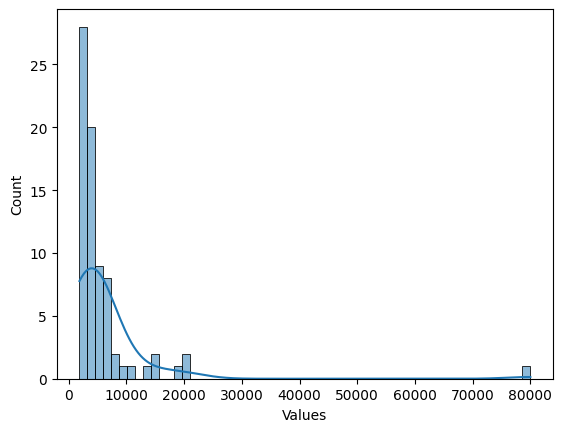

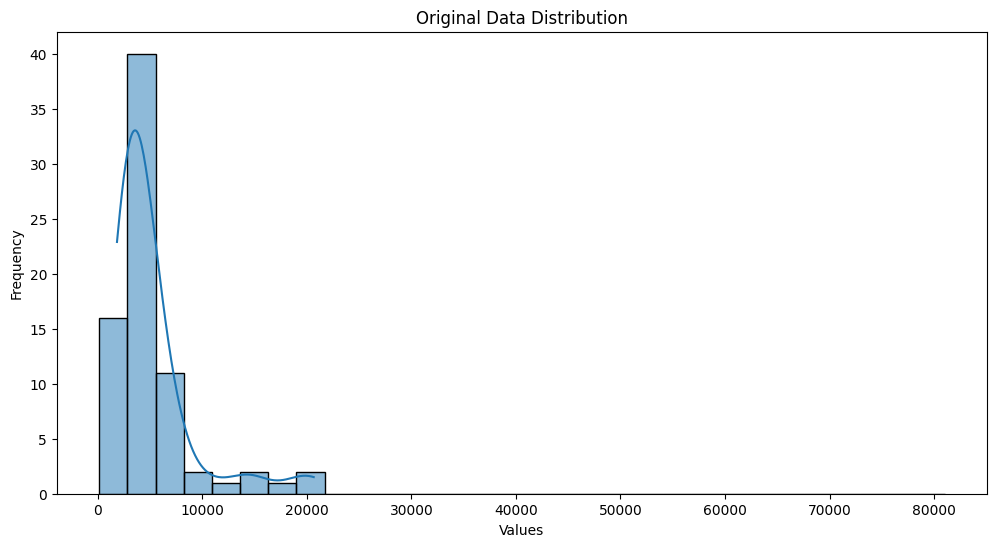

1.0564754087028696
0.14619522438488097


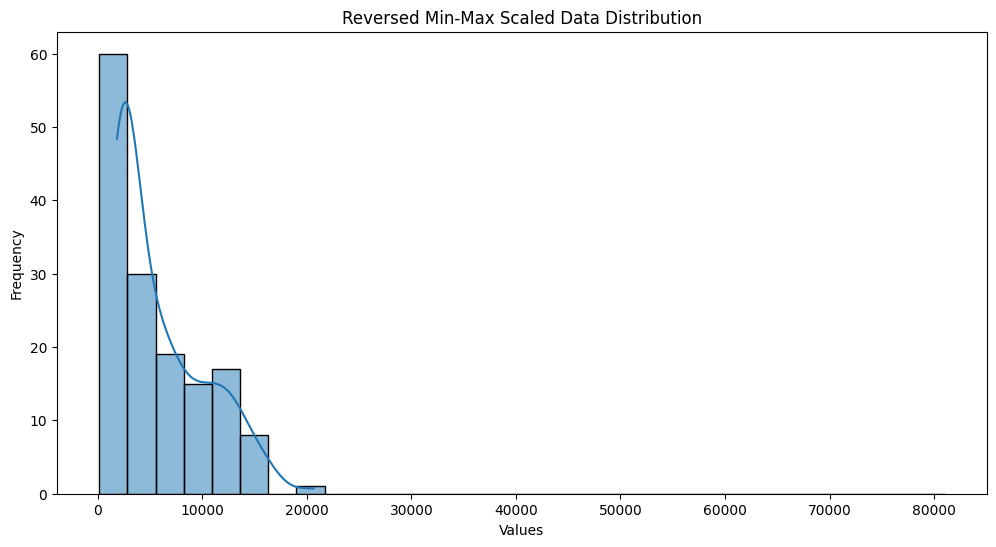

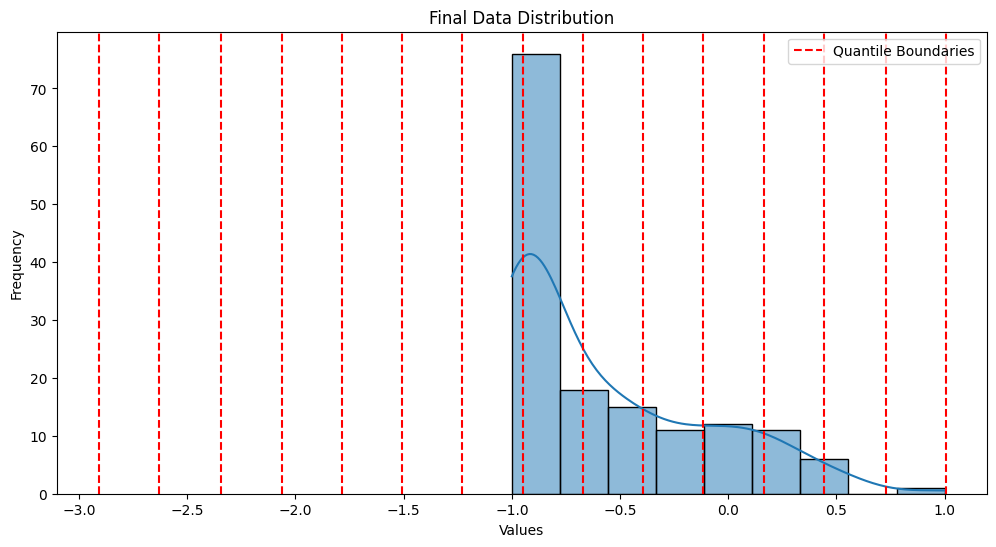

Quantile Boundaries: [-2.90713376 -2.62850868 -2.34380847 -2.06436168 -1.78628181 -1.5075227
 -1.22906007 -0.95037557 -0.67169107 -0.39322845 -0.11446934  0.16361053
  0.44305732  0.72775753  1.00638261]
Final Deviations: [  -1.   -4.  -13.  -34.  -71. -115. -109. -104.  -90.  -57.  -20.   -2.
    0.    0.]
Final Data Length: 150


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis, normaltest, norm
import matplotlib.pyplot as plt
import seaborn as sns

# Example Usage
data = pd.read_csv("/content/loan_approved.csv")

# Separate classes
y_class = data[(data['Loan_Status (Approved)'] == 'Y') & (data['ApplicantIncome'])]
n_class = data[(data['Loan_Status (Approved)'] == 'N') & (data['ApplicantIncome'])]
df = pd.DataFrame(n_class, columns=['ApplicantIncome']).rename(columns={'ApplicantIncome': 'Values'})
y_class = pd.DataFrame(y_class, columns=['ApplicantIncome']).rename(columns={'ApplicantIncome': 'Values'})
new_point = pd.DataFrame({'Values': [80000]})

# Concatenate the new point to the existing DataFrame
df = pd.concat([df, new_point], ignore_index=True)
print("New point added:", df.tail())
sns.histplot(df['Values'], kde=True)

expected_length = 150
print("Length of 'N' class:", len(n_class))
print("Expected length:", expected_length)
diff = expected_length - len(df)
print(diff)

# Ensure Values column is numeric and handle missing values
df['Values'] = pd.to_numeric(df['Values'], errors='coerce')
df = df.dropna()

# Step 1: Min-Max Normalization to range [-1, 1]
if not df.empty:
    df['Values'] = 2 * (df['Values'] - df['Values'].min()) / (df['Values'].max() - df['Values'].min()) - 1
else:
    raise ValueError("DataFrame 'df' is empty after filtering.")

# Step 2: Define Quartile Boundaries for Normal Distribution
mean = df['Values'].mean()
median = df['Values'].median()
#std =df['Values'].std()
std = (df['Values'].max() - median) / 3.5
print("Std:", std, "Mean:", mean)

# Define the quantile boundaries with appropriate extreme boundaries using percentiles
quantiles = [0.0013, 0.0062, 0.0228, 0.0668, 0.1587, 0.3085, 0.5, 0.6915, 0.8413, 0.9332, 0.9772, 0.9938, 0.9987]
quantile_boundaries = norm.ppf(quantiles, loc=median, scale=std)

# Calculate extreme boundaries
extreme_low = quantile_boundaries[0] - std / 2
extreme_high = quantile_boundaries[-1] + std / 2

# Concatenate boundaries
quantile_boundaries = np.concatenate(([extreme_low], quantile_boundaries, [extreme_high]))

# Ensure boundaries are strictly increasing
quantile_boundaries = np.sort(quantile_boundaries)

# Step 3: Find Deviations
def quantile_deviation(data, length_data, boundaries, expected_percentages):
    observed_counts = np.histogram(data, bins=boundaries)[0]
    expected_counts = expected_percentages * length_data
    deviations = observed_counts - np.round(expected_counts[:len(observed_counts)])
    return deviations, expected_counts, observed_counts

# Make sure expected_percentages matches the number of bins (number of boundaries - 1)
expected_percentages = np.array([0.13, 0.49, 1.66, 4.40, 9.19, 14.98, 19.15, 19.15, 14.98, 9.19, 4.40, 1.66, 0.49, 0.13]) / 100

# Calculate deviations
deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], len(df['Values']), quantile_boundaries, expected_percentages)
print("Initial Deviations:", deviations)

# Step 4: Adjust Sample Size
n = len(df)
max_deviation = np.max(deviations)
while max_deviation != 0:
    max_deviation_idx = np.argmax(deviations)
    max_deviation = deviations[max_deviation_idx]
    if (max_deviation > 0):
        n = observed_counts[max_deviation_idx] / expected_percentages[max_deviation_idx]
        n = int(np.round(n))
    else:
        break
    deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], n, quantile_boundaries, expected_percentages)

print("Desired sample size based on max deviation:", n)

# Calculate the expected count for values outside the range [-1, 1]
expected_counts_outside = sum(expected_counts[quantile_boundaries[:-1] < -1]) + sum(expected_counts[quantile_boundaries[1:] > 1])
print("Expected counts outside the range [-1, 1]:", expected_counts_outside)

if (n < expected_length):
    n = expected_length - int(expected_counts_outside)
    deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], n, quantile_boundaries, expected_percentages)

# Step 5: Add Points to Bins Below extreme boundaries
for i in range(len(quantile_boundaries) - 1):
    if (quantile_boundaries[i + 1] < -1) or (quantile_boundaries[i + 1] > 1):
        num_points_to_add = int(expected_counts[i] - observed_counts[i])
        if (num_points_to_add > 0):
            random_points = np.linspace(quantile_boundaries[i], quantile_boundaries[i + 1], num_points_to_add, endpoint=False)
            print(f"Adding points in range ({quantile_boundaries[i]}, {quantile_boundaries[i + 1]}): {random_points}")
            random_df = pd.DataFrame({'Values': random_points})
            df = pd.concat([df, random_df], ignore_index=True)

# Step 6: Calculate Final Deviations and Metrics
deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], n, quantile_boundaries, expected_percentages)
deviation_strengths = observed_counts / expected_counts
fractional_deficits = 1 - deviation_strengths
fractional_deficits[fractional_deficits < 0] = 0
print("Deviations after adjusting sample size:", deviations)
print("Fractional Deficits:", fractional_deficits)

# Step 7: Iteratively Add Points to Most Deficient Quantiles (one point at a time)
points_remaining = diff
while points_remaining > 0:
    # Extract fractional deficits and boundaries for quantiles within range [-1, 1]
    valid_indices = (quantile_boundaries[:-1] >= -1) & (quantile_boundaries[1:] <= 1)
    valid_fractional_deficits = fractional_deficits[valid_indices]
    valid_boundaries_start = quantile_boundaries[:-1][valid_indices]
    valid_boundaries_end = quantile_boundaries[1:][valid_indices]

    # Check if valid_fractional_deficits sum is zero to avoid division by zero
    if (valid_fractional_deficits.sum() == 0):
        # When all probabilities are zero, distribute points evenly using linspace
        remaining_points = np.linspace(max(quantile_boundaries[0], -1), min(quantile_boundaries[-1], 1), points_remaining, endpoint=False)
        random_df = pd.DataFrame({'Values': remaining_points})
        df = pd.concat([df, random_df], ignore_index=True)
        print(f"Adding points evenly in range [-1, 1]: {remaining_points}")
        points_remaining = 0  # All remaining points are added
    else:
        # Normalize fractional deficits to get probabilities
        probabilities = valid_fractional_deficits / valid_fractional_deficits.sum()

        # Select a quantile to add a point based on probabilities
        selected_idx = np.random.choice(len(probabilities), p=probabilities)

        # Add a single point to the selected quantile
        random_point = np.random.uniform(valid_boundaries_start[selected_idx], valid_boundaries_end[selected_idx])
        print(f"Adding point {random_point} in range ({valid_boundaries_start[selected_idx]}, {valid_boundaries_end[selected_idx]})")
        df = pd.concat([df, pd.DataFrame({'Values': [random_point]})], ignore_index=True)
        points_remaining -= 1

        # Recalculate deviations and fractional deficits after adding each point
        deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], n, quantile_boundaries, expected_percentages)
        deviation_strengths = observed_counts / expected_counts
        fractional_deficits = 1 - deviation_strengths
        fractional_deficits[fractional_deficits < 0] = 0

        # Recalculate valid fractional deficits
        valid_fractional_deficits = fractional_deficits[valid_indices]

    # Calculate the sum of fractional deficits for valid quantiles
    sum_fractional_deficits_valid = valid_fractional_deficits.sum()
    print("Sum of fractional deficits for quantiles within range [-1, 1]:", sum_fractional_deficits_valid)

print("Points remaining:", points_remaining)
print("Final Deviations:", deviations)
print("Fractional Deficits:", fractional_deficits)

# Remove points outside the extreme boundaries
df = df[(df['Values'] >= -1) & (df['Values'] <= 1)].reset_index(drop=True)

# Recalculate final deviations and metrics
deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], n, quantile_boundaries, expected_percentages)
skewness = skew(df['Values'])
kurt = kurtosis(df['Values'])
k2, p_value = normaltest(df['Values'])

# Print the results
print(f'Skewness: {skewness}')
print(f'Kurtosis: {kurt}')
print(f'P-value: {p_value}')

# Step 9: Visualization

# Calculate bin edges for the initial data
bin_edges = np.histogram_bin_edges(data['ApplicantIncome'], bins=30)

# Plotting the original data
plt.figure(figsize=(12, 6))
sns.histplot(n_class['ApplicantIncome'], bins=bin_edges, kde=True)
plt.title('Original Data Distribution')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()

# Reverse Min-Max Scaling on the new data
df['OriginalValues'] = (df['Values'] + 1) / 2 * (n_class['ApplicantIncome'].max() - n_class['ApplicantIncome'].min()) + n_class['ApplicantIncome'].min()
print(df['OriginalValues'].skew())
print(df['OriginalValues'].kurt())

# Plotting the reversed Min-Max scaled data with the same bin edges
plt.figure(figsize=(12, 6))
sns.histplot(df['OriginalValues'], bins=bin_edges, kde=True)
plt.title('Reversed Min-Max Scaled Data Distribution')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()

# Plotting the final data
plt.figure(figsize=(12, 6))
sns.histplot(df['Values'], kde=True)
plt.title('Final Data Distribution')
plt.xlabel('Values')
plt.ylabel('Frequency')
for boundary in quantile_boundaries:
    plt.axvline(x=boundary, color='r', linestyle='--', label='Quantile Boundaries' if boundary == quantile_boundaries[1] else "")
plt.legend()
plt.show()

# Display quantile boundaries
print(f'Quantile Boundaries: {quantile_boundaries}')
print(f'Final Deviations: {deviations}')
print(f'Final Data Length: {len(df)}')


New point added:     Values
71    4283
72    6383
73    2987
74    4583
75   80000
Length of 'N' class: 75
Expected length: 150
74
Std: 0.5572501640680841 Mean: -0.8903938124708294
Initial Deviations: [  0.   0.  -1.  -3.  -7. -11.  23.  17.  -6.  -7.  -3.  -1.   0.   1.]
Desired sample size based on max deviation: 769
Deviations after adjusting sample size: [  -1.   -4.  -13.  -34.  -71. -115. -109. -115. -110.  -71.  -34.  -13.
   -4.    0.]
Fractional Deficits: [1.         1.         1.         1.         1.         1.
 0.74195914 0.78270243 0.95659579 1.         1.         1.
 1.         0.        ]
Adding point -0.5749321145706577 in range (-0.6716910742005795, -0.39322844928373113)
Sum of fractional deficits for quantiles within range [-1, 1]: 5.730617383334687
Adding point -0.8920414218730122 in range (-0.9503755742382944, -0.6716910742005795)
Sum of fractional deficits for quantiles within range [-1, 1]: 5.723826834420665
Adding point 0.4224432151700633 in range (0.163610531789

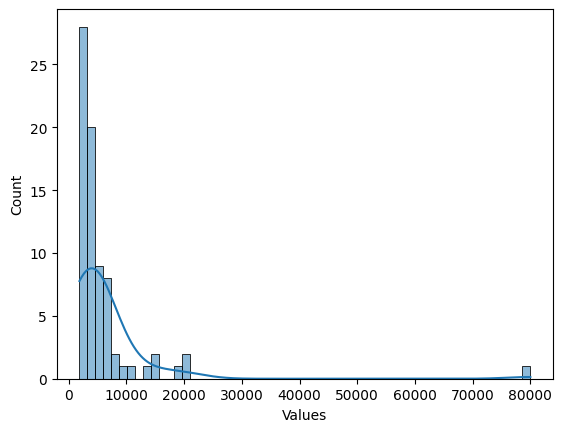

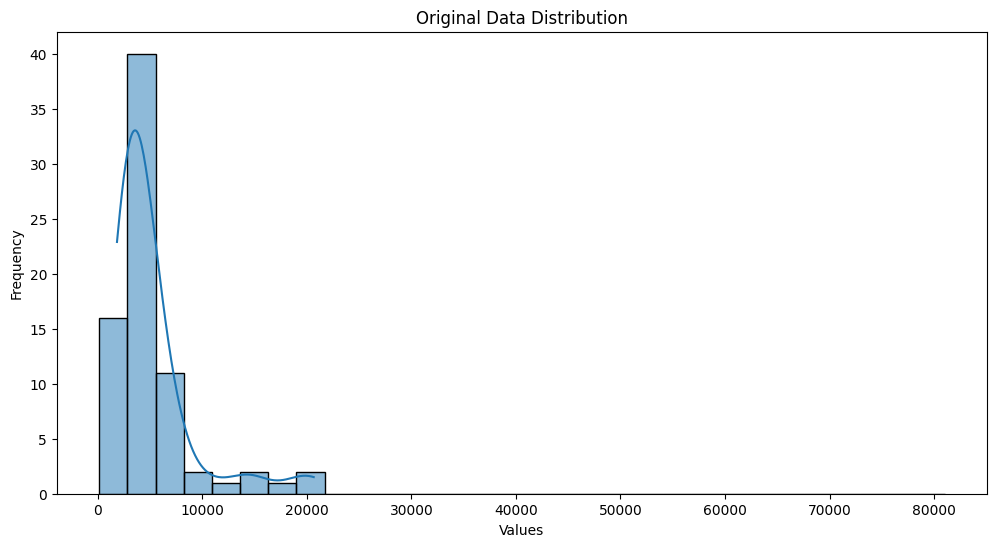

1.102232815623564
0.1575285101249655


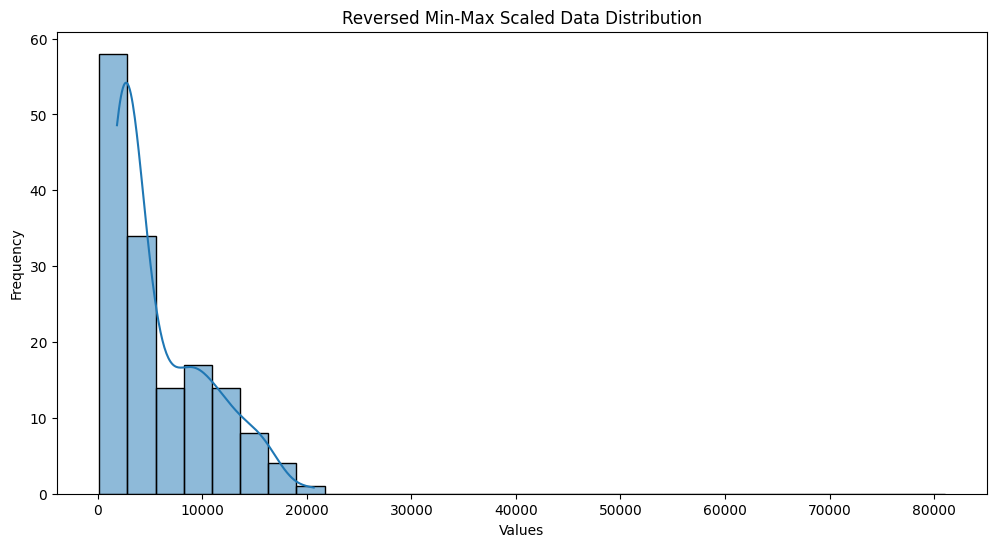

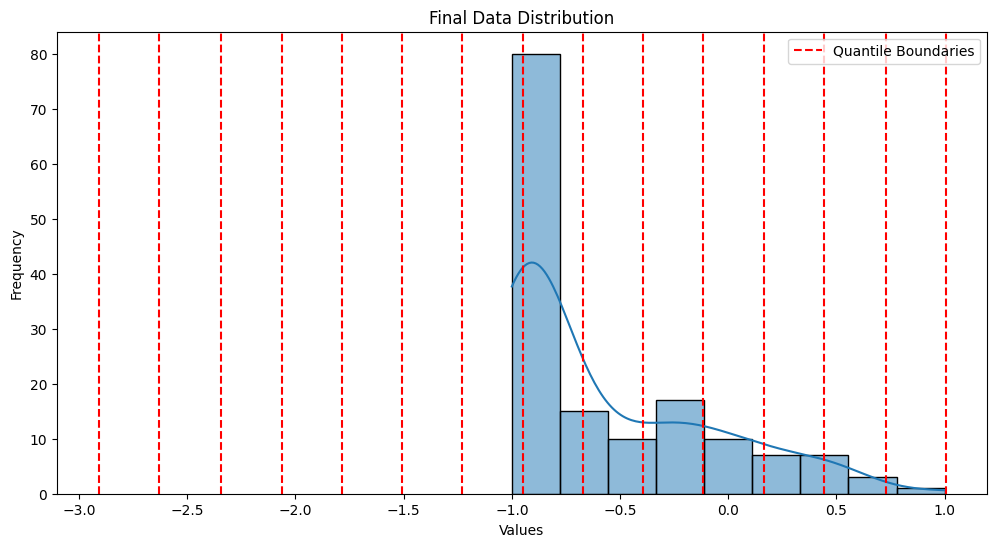

Quantile Boundaries: [-2.90713376 -2.62850868 -2.34380847 -2.06436168 -1.78628181 -1.5075227
 -1.22906007 -0.95037557 -0.67169107 -0.39322845 -0.11446934  0.16361053
  0.44305732  0.72775753  1.00638261]
Final Deviations: [  -1.   -4.  -13.  -34.  -71. -115. -109.  -97. -100.  -52.  -21.   -3.
    0.    0.]
Final Data Length: 150


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis, normaltest, norm
import matplotlib.pyplot as plt
import seaborn as sns

# Example Usage
data = pd.read_csv("/content/loan_approved.csv")

# Separate classes
y_class = data[(data['Loan_Status (Approved)'] == 'Y') & (data['ApplicantIncome'])]
n_class = data[(data['Loan_Status (Approved)'] == 'N') & (data['ApplicantIncome'])]
df = pd.DataFrame(n_class, columns=['ApplicantIncome']).rename(columns={'ApplicantIncome': 'Values'})
y_class = pd.DataFrame(y_class, columns=['ApplicantIncome']).rename(columns={'ApplicantIncome': 'Values'})
new_point = pd.DataFrame({'Values': [80000]})

# Concatenate the new point to the existing DataFrame
df = pd.concat([df, new_point], ignore_index=True)
print("New point added:", df.tail())
sns.histplot(df['Values'], kde=True)

expected_length = 150
print("Length of 'N' class:", len(n_class))
print("Expected length:", expected_length)
diff = expected_length - len(df)
print(diff)

# Ensure Values column is numeric and handle missing values
df['Values'] = pd.to_numeric(df['Values'], errors='coerce')
df = df.dropna()

# Step 1: Min-Max Normalization to range [-1, 1]
if not df.empty:
    df['Values'] = 2 * (df['Values'] - df['Values'].min()) / (df['Values'].max() - df['Values'].min()) - 1
else:
    raise ValueError("DataFrame 'df' is empty after filtering.")

# Step 2: Define Quartile Boundaries for Normal Distribution
mean = df['Values'].mean()
median = df['Values'].median()
#std =df['Values'].std()
std = (df['Values'].max() - median) / 3.5
print("Std:", std, "Mean:", mean)

# Define the quantile boundaries with appropriate extreme boundaries using percentiles
quantiles = [0.0013, 0.0062, 0.0228, 0.0668, 0.1587, 0.3085, 0.5, 0.6915, 0.8413, 0.9332, 0.9772, 0.9938, 0.9987]
quantile_boundaries = norm.ppf(quantiles, loc=median, scale=std)

# Calculate extreme boundaries
extreme_low = quantile_boundaries[0] - std / 2
extreme_high = quantile_boundaries[-1] + std / 2

# Concatenate boundaries
quantile_boundaries = np.concatenate(([extreme_low], quantile_boundaries, [extreme_high]))

# Ensure boundaries are strictly increasing
quantile_boundaries = np.sort(quantile_boundaries)

# Step 3: Find Deviations
def quantile_deviation(data, length_data, boundaries, expected_percentages):
    observed_counts = np.histogram(data, bins=boundaries)[0]
    expected_counts = expected_percentages * length_data
    deviations = observed_counts - np.round(expected_counts[:len(observed_counts)])
    return deviations, expected_counts, observed_counts

# Make sure expected_percentages matches the number of bins (number of boundaries - 1)
expected_percentages = np.array([0.13, 0.49, 1.66, 4.40, 9.19, 14.98, 19.15, 19.15, 14.98, 9.19, 4.40, 1.66, 0.49, 0.13]) / 100

# Calculate deviations
deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], len(df['Values']), quantile_boundaries, expected_percentages)
print("Initial Deviations:", deviations)

# Step 4: Adjust Sample Size
n = len(df)
max_deviation = np.max(deviations)
while max_deviation != 0:
    max_deviation_idx = np.argmax(deviations)
    max_deviation = deviations[max_deviation_idx]
    if (max_deviation > 0):
        n = observed_counts[max_deviation_idx] / expected_percentages[max_deviation_idx]
        n = int(np.round(n))
    else:
        break
    deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], n, quantile_boundaries, expected_percentages)

print("Desired sample size based on max deviation:", n)


# Step 6: Calculate Final Deviations and Metrics
deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], n, quantile_boundaries, expected_percentages)
deviation_strengths = observed_counts / expected_counts
fractional_deficits = 1 - deviation_strengths
fractional_deficits[fractional_deficits < 0] = 0
print("Deviations after adjusting sample size:", deviations)
print("Fractional Deficits:", fractional_deficits)

# Step 7: Iteratively Add Points to Most Deficient Quantiles (one point at a time)
points_remaining = diff
while points_remaining > 0:
    # Extract fractional deficits and boundaries for quantiles within range [-1, 1]
    valid_indices = (quantile_boundaries[:-1] >= -1) & (quantile_boundaries[1:] <= 1)
    valid_fractional_deficits = fractional_deficits[valid_indices]
    valid_boundaries_start = quantile_boundaries[:-1][valid_indices]
    valid_boundaries_end = quantile_boundaries[1:][valid_indices]

    # Check if valid_fractional_deficits sum is zero to avoid division by zero
    if (valid_fractional_deficits.sum() == 0):
        # When all probabilities are zero, distribute points evenly using linspace
        remaining_points = np.linspace(max(quantile_boundaries[0], -1), min(quantile_boundaries[-1], 1), points_remaining, endpoint=False)
        random_df = pd.DataFrame({'Values': remaining_points})
        df = pd.concat([df, random_df], ignore_index=True)
        print(f"Adding points evenly in range [-1, 1]: {remaining_points}")
        points_remaining = 0  # All remaining points are added
    else:
        # Normalize fractional deficits to get probabilities
        probabilities = valid_fractional_deficits / valid_fractional_deficits.sum()

        # Select a quantile to add a point based on probabilities
        selected_idx = np.random.choice(len(probabilities), p=probabilities)

        # Add a single point to the selected quantile
        random_point = np.random.uniform(valid_boundaries_start[selected_idx], valid_boundaries_end[selected_idx])
        print(f"Adding point {random_point} in range ({valid_boundaries_start[selected_idx]}, {valid_boundaries_end[selected_idx]})")
        df = pd.concat([df, pd.DataFrame({'Values': [random_point]})], ignore_index=True)
        points_remaining -= 1

        # Recalculate deviations and fractional deficits after adding each point
        deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], n, quantile_boundaries, expected_percentages)
        deviation_strengths = observed_counts / expected_counts
        fractional_deficits = 1 - deviation_strengths
        fractional_deficits[fractional_deficits < 0] = 0

        # Recalculate valid fractional deficits
        valid_fractional_deficits = fractional_deficits[valid_indices]

    # Calculate the sum of fractional deficits for valid quantiles
    sum_fractional_deficits_valid = valid_fractional_deficits.sum()
    print("Sum of fractional deficits for quantiles within range [-1, 1]:", sum_fractional_deficits_valid)

print("Points remaining:", points_remaining)
print("Final Deviations:", deviations)
print("Fractional Deficits:", fractional_deficits)

# Remove points outside the extreme boundaries
df = df[(df['Values'] >= -1) & (df['Values'] <= 1)].reset_index(drop=True)

# Recalculate final deviations and metrics
deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], n, quantile_boundaries, expected_percentages)
skewness = skew(df['Values'])
kurt = kurtosis(df['Values'])
k2, p_value = normaltest(df['Values'])

# Print the results
print(f'Skewness: {skewness}')
print(f'Kurtosis: {kurt}')
print(f'P-value: {p_value}')

# Step 9: Visualization

# Calculate bin edges for the initial data
bin_edges = np.histogram_bin_edges(data['ApplicantIncome'], bins=30)

# Plotting the original data
plt.figure(figsize=(12, 6))
sns.histplot(n_class['ApplicantIncome'], bins=bin_edges, kde=True)
plt.title('Original Data Distribution')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()

# Reverse Min-Max Scaling on the new data
df['OriginalValues'] = (df['Values'] + 1) / 2 * (n_class['ApplicantIncome'].max() - n_class['ApplicantIncome'].min()) + n_class['ApplicantIncome'].min()
print(df['OriginalValues'].skew())
print(df['OriginalValues'].kurt())

# Plotting the reversed Min-Max scaled data with the same bin edges
plt.figure(figsize=(12, 6))
sns.histplot(df['OriginalValues'], bins=bin_edges, kde=True)
plt.title('Reversed Min-Max Scaled Data Distribution')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()

# Plotting the final data
plt.figure(figsize=(12, 6))
sns.histplot(df['Values'], kde=True)
plt.title('Final Data Distribution')
plt.xlabel('Values')
plt.ylabel('Frequency')
for boundary in quantile_boundaries:
    plt.axvline(x=boundary, color='r', linestyle='--', label='Quantile Boundaries' if boundary == quantile_boundaries[1] else "")
plt.legend()
plt.show()

# Display quantile boundaries
print(f'Quantile Boundaries: {quantile_boundaries}')
print(f'Final Deviations: {deviations}')
print(f'Final Data Length: {len(df)}')


-----------------------------------------------------------------------

---


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis, normaltest, norm
import matplotlib.pyplot as plt
import seaborn as sns

# Example Usage
data = pd.read_csv("/content/loan_approved.csv")

# Separate classes
y_class = data[(data['Loan_Status (Approved)'] == 'Y') & (data['ApplicantIncome'])]
n_class = data[(data['Loan_Status (Approved)'] == 'N') & (data['ApplicantIncome'])]
df = pd.DataFrame(n_class, columns=['ApplicantIncome']).rename(columns={'ApplicantIncome': 'Values'})
y_class = pd.DataFrame(y_class, columns=['ApplicantIncome']).rename(columns={'ApplicantIncome': 'Values'})
new_point = pd.DataFrame({'Values': [80000]})

# Concatenate the new point to the existing DataFrame
df = pd.concat([df, new_point], ignore_index=True)
print("New point added:", df.tail())
sns.histplot(df['Values'], kde=True)

expected_length = 150
print("Length of 'N' class:", len(n_class))
print("Expected length:", expected_length)
diff = expected_length - len(df)
print(diff)

# Ensure Values column is numeric and handle missing values
df['Values'] = pd.to_numeric(df['Values'], errors='coerce')
df = df.dropna()

# Step 1: Min-Max Normalization to range [-1, 1]
if not df.empty:
    df['Values'] = 2 * (df['Values'] - df['Values'].min()) / (df['Values'].max() - df['Values'].min()) - 1
else:
    raise ValueError("DataFrame 'df' is empty after filtering.")

# Step 2: Define Quartile Boundaries for Normal Distribution
mean = df['Values'].mean()
median = df['Values'].median()
#std =df['Values'].std()
std = (df['Values'].max() - median) / 3.5
print("Std:", std, "Mean:", mean)

# Define the quantile boundaries with appropriate extreme boundaries using percentiles
quantiles = [0.0013, 0.0062, 0.0228, 0.0668, 0.1587, 0.3085, 0.5, 0.6915, 0.8413, 0.9332, 0.9772, 0.9938, 0.9987]
quantile_boundaries = norm.ppf(quantiles, loc=median, scale=std)

# Calculate extreme boundaries
extreme_low = quantile_boundaries[0] - std / 2
extreme_high = quantile_boundaries[-1] + std / 2

# Concatenate boundaries
quantile_boundaries = np.concatenate(([extreme_low], quantile_boundaries, [extreme_high]))

# Ensure boundaries are strictly increasing
quantile_boundaries = np.sort(quantile_boundaries)

# Step 3: Find Deviations
def quantile_deviation(data, length_data, boundaries, expected_percentages):
    observed_counts = np.histogram(data, bins=boundaries)[0]
    expected_counts = expected_percentages * length_data
    deviations = observed_counts - np.round(expected_counts[:len(observed_counts)])
    return deviations, expected_counts, observed_counts

# Make sure expected_percentages matches the number of bins (number of boundaries - 1)
expected_percentages = np.array([0.13, 0.49, 1.66, 4.40, 9.19, 14.98, 19.15, 19.15, 14.98, 9.19, 4.40, 1.66, 0.49, 0.13]) / 100

# Calculate deviations
deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], len(df['Values']), quantile_boundaries, expected_percentages)
print("Initial Deviations:", deviations)

# Step 4: Adjust Sample Size
n = len(df)
max_deviation = np.max(deviations)
while max_deviation != 0:
    max_deviation_idx = np.argmax(deviations)
    max_deviation = deviations[max_deviation_idx]
    if (max_deviation > 0):
        n = observed_counts[max_deviation_idx] / expected_percentages[max_deviation_idx]
        n = int(np.round(n))
    else:
        break
    deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], n, quantile_boundaries, expected_percentages)

print("Desired sample size based on max deviation:", n)


# Step 6: Calculate Final Deviations and Metrics
deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], n, quantile_boundaries, expected_percentages)
deviation_strengths = observed_counts / expected_counts
fractional_deficits = 1 - deviation_strengths
fractional_deficits[fractional_deficits < 0] = 0
print("Deviations after adjusting sample size:", deviations)
print("Fractional Deficits:", fractional_deficits)

# Step 7: Iteratively Add Points to Most Deficient Quantiles (one point at a time)
points_remaining = diff
while points_remaining > 0:
    # Extract fractional deficits and boundaries for quantiles within range [-1, 1]
    valid_indices = (quantile_boundaries[:-1] >= -1) & (quantile_boundaries[1:] <= 1)
    valid_fractional_deficits = fractional_deficits[valid_indices]
    valid_boundaries_start = quantile_boundaries[:-1][valid_indices]
    valid_boundaries_end = quantile_boundaries[1:][valid_indices]

    # Check if valid_fractional_deficits sum is zero to avoid division by zero
    if (valid_fractional_deficits.sum() == 0):
        # When all probabilities are zero, distribute points evenly using linspace
        remaining_points = np.linspace(max(quantile_boundaries[0], -1), min(quantile_boundaries[-1], 1), points_remaining, endpoint=False)
        random_df = pd.DataFrame({'Values': remaining_points})
        df = pd.concat([df, random_df], ignore_index=True)
        print(f"Adding points evenly in range [-1, 1]: {remaining_points}")
        points_remaining = 0  # All remaining points are added
    else:
        # Normalize fractional deficits to get probabilities
        probabilities = valid_fractional_deficits / valid_fractional_deficits.sum()

        # Select a quantile to add a point based on probabilities
        selected_idx = np.random.choice(len(probabilities), p=probabilities)

        # Add a single point to the selected quantile
        random_point = np.random.uniform(valid_boundaries_start[selected_idx], valid_boundaries_end[selected_idx])
        print(f"Adding point {random_point} in range ({valid_boundaries_start[selected_idx]}, {valid_boundaries_end[selected_idx]})")
        df = pd.concat([df, pd.DataFrame({'Values': [random_point]})], ignore_index=True)
        points_remaining -= 1

        # Recalculate deviations and fractional deficits after adding each point
        deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], n, quantile_boundaries, expected_percentages)
        deviation_strengths = observed_counts / expected_counts
        fractional_deficits = 1 - deviation_strengths
        fractional_deficits[fractional_deficits < 0] = 0

        # Recalculate valid fractional deficits
        valid_fractional_deficits = fractional_deficits[valid_indices]

    # Calculate the sum of fractional deficits for valid quantiles
    sum_fractional_deficits_valid = valid_fractional_deficits.sum()
    print("Sum of fractional deficits for quantiles within range [-1, 1]:", sum_fractional_deficits_valid)

print("Points remaining:", points_remaining)
print("Final Deviations:", deviations)
print("Fractional Deficits:", fractional_deficits)

# Remove points outside the extreme boundaries
df = df[(df['Values'] >= -1) & (df['Values'] <= 1)].reset_index(drop=True)

# Recalculate final deviations and metrics
deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], n, quantile_boundaries, expected_percentages)
skewness = skew(df['Values'])
kurt = kurtosis(df['Values'])
k2, p_value = normaltest(df['Values'])

# Print the results
print(f'Skewness: {skewness}')
print(f'Kurtosis: {kurt}')
print(f'P-value: {p_value}')

# Step 9: Visualization

# Calculate bin edges for the initial data
bin_edges = np.histogram_bin_edges(data['ApplicantIncome'], bins=30)

# Plotting the original data
plt.figure(figsize=(12, 6))
sns.histplot(n_class['ApplicantIncome'], bins=bin_edges, kde=True)
plt.title('Original Data Distribution')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()

# Reverse Min-Max Scaling on the new data
df['OriginalValues'] = (df['Values'] + 1) / 2 * (n_class['ApplicantIncome'].max() - n_class['ApplicantIncome'].min()) + n_class['ApplicantIncome'].min()
print(df['OriginalValues'].skew())
print(df['OriginalValues'].kurt())

# Plotting the reversed Min-Max scaled data with the same bin edges
plt.figure(figsize=(12, 6))
sns.histplot(df['OriginalValues'], bins=bin_edges, kde=True)
plt.title('Reversed Min-Max Scaled Data Distribution')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()

# Plotting the final data
plt.figure(figsize=(12, 6))
sns.histplot(df['Values'], kde=True)
plt.title('Final Data Distribution')
plt.xlabel('Values')
plt.ylabel('Frequency')
for boundary in quantile_boundaries:
    plt.axvline(x=boundary, color='r', linestyle='--', label='Quantile Boundaries' if boundary == quantile_boundaries[1] else "")
plt.legend()
plt.show()

# Display quantile boundaries
print(f'Quantile Boundaries: {quantile_boundaries}')
print(f'Final Deviations: {deviations}')
print(f'Final Data Length: {len(df)}')




---



---



In [ ]:
def min_max(df):
  # Ensure Values column is numeric and handle missing values
  df['Values'] = pd.to_numeric(df['Values'], errors='coerce')
  df = df.dropna()
  # Step 1: Min-Max Normalization to range [-1, 1]
  if not df.empty:
    df['Values'] = 2 * (df['Values'] - df['Values'].min()) / (df['Values'].max() - df['Values'].min()) - 1
  else:
    raise ValueError("DataFrame 'df' is empty after filtering.")

    # Step 2: Define Quartile Boundaries for Normal Distribution
  mean = df['Values'].mean()
  median = df['Values'].median()
  #std =df['Values'].std()
  std = (df['Values'].max() - median) / 3.5
  print("Std:", std, "Mean:", mean)

  # Define the quantile boundaries with appropriate extreme boundaries using percentiles
  quantiles = [0.0013, 0.0062, 0.0228, 0.0668, 0.1587, 0.3085, 0.5, 0.6915, 0.8413, 0.9332, 0.9772, 0.9938, 0.9987]
  quantile_boundaries = norm.ppf(quantiles, loc=median, scale=std)

  # Calculate extreme boundaries
  extreme_low = quantile_boundaries[0] - std / 2
  extreme_high = quantile_boundaries[-1] + std / 2

  # Concatenate boundaries
  quantile_boundaries = np.concatenate(([extreme_low], quantile_boundaries, [extreme_high]))

  # Ensure boundaries are strictly increasing
  quantile_boundaries = np.sort(quantile_boundaries)
  return df, quantile_boundaries

In [ ]:
def quantile_deviation(data, length_data, boundaries):
    observed_counts = np.histogram(data, bins=boundaries)[0]
    expected_percentages = np.array([0.13, 0.49, 1.66, 4.40, 9.19, 14.98, 19.15, 19.15, 14.98, 9.19, 4.40, 1.66, 0.49, 0.13]) / 100
    expected_counts = expected_percentages * length_data
    deviations = observed_counts - np.round(expected_counts[:len(observed_counts)])
    return deviations, expected_counts, observed_counts


In [ ]:
def adjust_lenght(df,deviations):
  n = len(df)
  max_deviation = np.max(deviations)
  while max_deviation != 0:
      max_deviation_idx = np.argmax(deviations)
      max_deviation = deviations[max_deviation_idx]
      if (max_deviation > 0):
          n = observed_counts[max_deviation_idx] / expected_percentages[max_deviation_idx]
          n = int(np.round(n))
      else:
          break
      deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], n, quantile_boundaries)
  return n
  print("Desired sample size based on max deviation:", n)

In [ ]:
def add_points(df,n,quantile_boundaries):
  # Step 6: Calculate Final Deviations and Metrics
  deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], n, quantile_boundaries)
  deviation_strengths = observed_counts / expected_counts
  fractional_deficits = 1 - deviation_strengths
  fractional_deficits[fractional_deficits < 0] = 0
  print("Deviations after adjusting sample size:", deviations)
  print("Fractional Deficits:", fractional_deficits)

  # Step 7: Iteratively Add Points to Most Deficient Quantiles (one point at a time)
  points_remaining = diff
  while points_remaining > 0:
      # Extract fractional deficits and boundaries for quantiles within range [-1, 1]
      valid_indices = (quantile_boundaries[:-1] >= -1) & (quantile_boundaries[1:] <= 1)
      valid_fractional_deficits = fractional_deficits[valid_indices]
      valid_boundaries_start = quantile_boundaries[:-1][valid_indices]
      valid_boundaries_end = quantile_boundaries[1:][valid_indices]

      # Check if valid_fractional_deficits sum is zero to avoid division by zero
      if (valid_fractional_deficits.sum() == 0):
          # When all probabilities are zero, distribute points evenly using linspace
          remaining_points = np.linspace(max(quantile_boundaries[0], -1), min(quantile_boundaries[-1], 1), points_remaining, endpoint=False)
          random_df = pd.DataFrame({'Values': remaining_points})
          df = pd.concat([df, random_df], ignore_index=True)
          print(f"Adding points evenly in range [-1, 1]: {remaining_points}")
          points_remaining = 0  # All remaining points are added
      else:
          # Normalize fractional deficits to get probabilities
          probabilities = valid_fractional_deficits / valid_fractional_deficits.sum()

          # Select a quantile to add a point based on probabilities
          selected_idx = np.random.choice(len(probabilities), p=probabilities)

          # Add a single point to the selected quantile
          random_point = np.random.uniform(valid_boundaries_start[selected_idx], valid_boundaries_end[selected_idx])
          print(f"Adding point {random_point} in range ({valid_boundaries_start[selected_idx]}, {valid_boundaries_end[selected_idx]})")
          df = pd.concat([df, pd.DataFrame({'Values': [random_point]})], ignore_index=True)
          points_remaining -= 1

          # Recalculate deviations and fractional deficits after adding each point
          deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], n, quantile_boundaries)
          deviation_strengths = observed_counts / expected_counts
          fractional_deficits = 1 - deviation_strengths
          fractional_deficits[fractional_deficits < 0] = 0

          # Recalculate valid fractional deficits
          valid_fractional_deficits = fractional_deficits[valid_indices]

      # Calculate the sum of fractional deficits for valid quantiles
      sum_fractional_deficits_valid = valid_fractional_deficits.sum()
      print("Sum of fractional deficits for quantiles within range [-1, 1]:", sum_fractional_deficits_valid)

  print("Points remaining:", points_remaining)
  print("Final Deviations:", deviations)
  print("Fractional Deficits:", fractional_deficits)


In [ ]:
def results(df,n,quantile_boundaries,n_class):
  # Recalculate final deviations and metrics
  deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], n, quantile_boundaries)
  skewness = skew(df['Values'])
  kurt = kurtosis(df['Values'])
  k2, p_value = normaltest(df['Values'])

  # Print the results
  print(f'Skewness: {skewness}')
  print(f'Kurtosis: {kurt}')
  print(f'P-value: {p_value}')

# Step 9: Visualization

# Calculate bin edges for the initial data
  bin_edges = np.histogram_bin_edges(data['ApplicantIncome'], bins=30)

# Plotting the original data
  plt.figure(figsize=(12, 6))
  sns.histplot(n_class['ApplicantIncome'], bins=bin_edges, kde=True)
  plt.title('Original Data Distribution')
  plt.xlabel('Values')
  plt.ylabel('Frequency')
  plt.show()

  # Reverse Min-Max Scaling on the new data
  df['OriginalValues'] = (df['Values'] + 1) / 2 * (n_class['ApplicantIncome'].max() - n_class['ApplicantIncome'].min()) + n_class['ApplicantIncome'].min()
  print(df['OriginalValues'].skew())
  print(df['OriginalValues'].kurt())

  # Plotting the reversed Min-Max scaled data with the same bin edges
  plt.figure(figsize=(12, 6))
  sns.histplot(df['OriginalValues'], bins=bin_edges, kde=True)
  plt.title('Reversed Min-Max Scaled Data Distribution')
  plt.xlabel('Values')
  plt.ylabel('Frequency')
  plt.show()

  # Plotting the final data
  plt.figure(figsize=(12, 6))
  sns.histplot(df['Values'], kde=True)
  plt.title('Final Data Distribution')
  plt.xlabel('Values')
  plt.ylabel('Frequency')
  for boundary in quantile_boundaries:
      plt.axvline(x=boundary, color='r', linestyle='--', label='Quantile Boundaries' if boundary == quantile_boundaries[1] else "")
  plt.legend()
  plt.show()

  # Display quantile boundaries
  print(f'Quantile Boundaries: {quantile_boundaries}')
  print(f'Final Deviations: {deviations}')
  print(f'Final Data Length: {len(df)}')


New point added:     Values
71    4283
72    6383
73    2987
74    4583
75   80000
Length of 'N' class: 75
Expected length: 150
74
Std: 0.5572501640680841 Mean: -0.8903938124708294


UnboundLocalError: local variable 'observed_counts' referenced before assignment

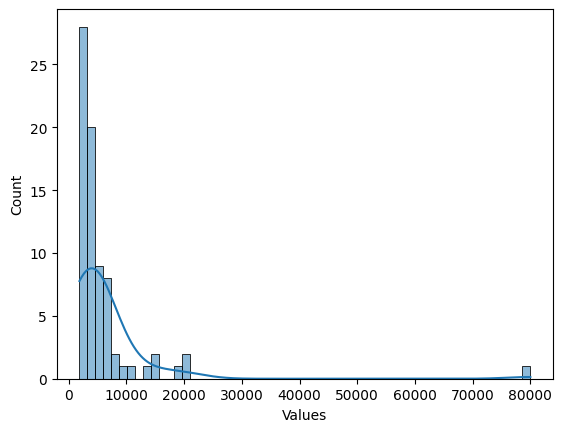

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis, normaltest, norm
import matplotlib.pyplot as plt
import seaborn as sns

# Example Usage
data = pd.read_csv("/content/loan_approved.csv")

# Separate classes
y_class = data[(data['Loan_Status (Approved)'] == 'Y') & (data['ApplicantIncome'])]
n_class = data[(data['Loan_Status (Approved)'] == 'N') & (data['ApplicantIncome'])]
df = pd.DataFrame(n_class, columns=['ApplicantIncome']).rename(columns={'ApplicantIncome': 'Values'})
y_class = pd.DataFrame(y_class, columns=['ApplicantIncome']).rename(columns={'ApplicantIncome': 'Values'})
new_point = pd.DataFrame({'Values': [80000]})

# Concatenate the new point to the existing DataFrame
df = pd.concat([df, new_point], ignore_index=True)
print("New point added:", df.tail())
sns.histplot(df['Values'], kde=True)

expected_length = 150
print("Length of 'N' class:", len(n_class))
print("Expected length:", expected_length)
diff = expected_length - len(df)
print(diff)

df, quantile_boundaries = min_max(df)
n = adjust_lenght(df,deviations)
add_points(df,n,quantile_boundaries)
results(df,n,quantile_boundaries,n_class)




---



---



In [ ]:
def min_max(df):
    # Ensure Values column is numeric and handle missing values
    df['Values'] = pd.to_numeric(df['Values'], errors='coerce')
    df = df.dropna()

    # Step 1: Min-Max Normalization to range [-1, 1]
    if not df.empty:
        df['Values'] = 2 * (df['Values'] - df['Values'].min()) / (df['Values'].max() - df['Values'].min()) - 1
    else:
        raise ValueError("DataFrame 'df' is empty after filtering.")

    # Step 2: Define Quartile Boundaries for Normal Distribution
    mean = df['Values'].mean()
    median = df['Values'].median()
    std = (df['Values'].max() - median) / 3.5
    print("Std:", std, "Mean:", mean)

    # Define the quantile boundaries with appropriate extreme boundaries using percentiles
    quantiles = [0.0013, 0.0062, 0.0228, 0.0668, 0.1587, 0.3085, 0.5, 0.6915, 0.8413, 0.9332, 0.9772, 0.9938, 0.9987]
    quantile_boundaries = norm.ppf(quantiles, loc=median, scale=std)

    # Calculate extreme boundaries
    extreme_low = quantile_boundaries[0] - std / 2
    extreme_high = quantile_boundaries[-1] + std / 2

    # Concatenate boundaries
    quantile_boundaries = np.concatenate(([extreme_low], quantile_boundaries, [extreme_high]))

    # Ensure boundaries are strictly increasing
    quantile_boundaries = np.sort(quantile_boundaries)
    return df, quantile_boundaries


In [ ]:
def quantile_deviation(data, length_data, boundaries):
    observed_counts = np.histogram(data, bins=boundaries)[0]
    expected_percentages = np.array([0.13, 0.49, 1.66, 4.40, 9.19, 14.98, 19.15, 19.15, 14.98, 9.19, 4.40, 1.66, 0.49, 0.13]) / 100
    expected_counts = expected_percentages * length_data
    deviations = observed_counts - np.round(expected_counts[:len(observed_counts)])
    return deviations, expected_counts, observed_counts


In [ ]:
def adjust_length(df, deviations, expected_percentages, quantile_boundaries):
    max_deviation_idx = np.argmax(deviations)
    max_deviation = deviations[max_deviation_idx]
    if max_deviation > 0:
        n = observed_counts[max_deviation_idx] / expected_percentages[max_deviation_idx]
        n = int(np.round(n))
    else:
        n = len(df)
    return n


In [ ]:
def add_points(df, n, quantile_boundaries, diff):
    deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], n, quantile_boundaries)
    deviation_strengths = observed_counts / expected_counts
    fractional_deficits = 1 - deviation_strengths
    fractional_deficits[fractional_deficits < 0] = 0
    print("Deviations after adjusting sample size:", deviations)
    print("Fractional Deficits:", fractional_deficits)

    points_remaining = diff
    while points_remaining > 0:
        valid_indices = (quantile_boundaries[:-1] >= -1) & (quantile_boundaries[1:] <= 1)
        valid_fractional_deficits = fractional_deficits[valid_indices]
        valid_boundaries_start = quantile_boundaries[:-1][valid_indices]
        valid_boundaries_end = quantile_boundaries[1:][valid_indices]

        if valid_fractional_deficits.sum() == 0:
            remaining_points = np.linspace(max(quantile_boundaries[0], -1), min(quantile_boundaries[-1], 1), points_remaining, endpoint=False)
            random_df = pd.DataFrame({'Values': remaining_points})
            df = pd.concat([df, random_df], ignore_index=True)
            print(f"Adding points evenly in range [-1, 1]: {remaining_points}")
            points_remaining = 0
        else:
            probabilities = valid_fractional_deficits / valid_fractional_deficits.sum()
            selected_idx = np.random.choice(len(probabilities), p=probabilities)
            random_point = np.random.uniform(valid_boundaries_start[selected_idx], valid_boundaries_end[selected_idx])
            print(f"Adding point {random_point} in range ({valid_boundaries_start[selected_idx]}, {valid_boundaries_end[selected_idx]})")
            df = pd.concat([df, pd.DataFrame({'Values': [random_point]})], ignore_index=True)
            points_remaining -= 1

            deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], n, quantile_boundaries)
            deviation_strengths = observed_counts / expected_counts
            fractional_deficits = 1 - deviation_strengths
            fractional_deficits[fractional_deficits < 0] = 0
            valid_fractional_deficits = fractional_deficits[valid_indices]

        sum_fractional_deficits_valid = valid_fractional_deficits.sum()
        print("Sum of fractional deficits for quantiles within range [-1, 1]:", sum_fractional_deficits_valid)

    print("Points remaining:", points_remaining)
    print("Final Deviations:", deviations)
    print("Fractional Deficits:", fractional_deficits)


In [ ]:
def results(df, n, quantile_boundaries, n_class):
    deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], n, quantile_boundaries)
    skewness = skew(df['Values'])
    kurt = kurtosis(df['Values'])
    k2, p_value = normaltest(df['Values'])

    print(f'Skewness: {skewness}')
    print(f'Kurtosis: {kurt}')
    print(f'P-value: {p_value}')

    bin_edges = np.histogram_bin_edges(n_class['Values'], bins=30)

    plt.figure(figsize=(12, 6))
    sns.histplot(n_class['Values'], bins=bin_edges, kde=True)
    plt.title('Original Data Distribution')
    plt.xlabel('Values')
    plt.ylabel('Frequency')
    plt.show()

    df['OriginalValues'] = (df['Values'] + 1) / 2 * (n_class['Values'].max() - n_class['Values'].min()) + n_class['Values'].min()
    print(df['OriginalValues'].skew())
    print(df['OriginalValues'].kurt())

    plt.figure(figsize=(12, 6))
    sns.histplot(df['OriginalValues'], bins=bin_edges, kde=True)
    plt.title('Reversed Min-Max Scaled Data Distribution')
    plt.xlabel('Values')
    plt.ylabel('Frequency')
    plt.show()

    plt.figure(figsize=(12, 6))
    sns.histplot(df['Values'], kde=True)
    plt.title('Final Data Distribution')
    plt.xlabel('Values')
    plt.ylabel('Frequency')
    for boundary in quantile_boundaries:
        plt.axvline(x=boundary, color='r', linestyle='--', label='Quantile Boundaries' if boundary == quantile_boundaries[1] else "")
    plt.legend()
    plt.show()

    print(f'Quantile Boundaries: {quantile_boundaries}')
    print(f'Final Deviations: {deviations}')
    print(f'Final Data Length: {len(df)}')


New point added:     Values
71    4283
72    6383
73    2987
74    4583
75   80000
Length of 'N' class: 75
Expected length: 221
145
Std: 0.5572501640680841 Mean: -0.8903938124708294


TypeError: quantile_deviation() missing 1 required positional argument: 'expected_percentages'

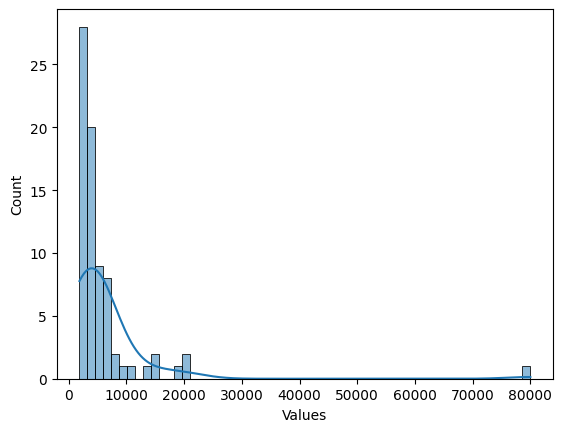

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis, normaltest, norm
import matplotlib.pyplot as plt
import seaborn as sns

# Example Usage
data = pd.read_csv("/content/loan_approved.csv")

# Separate classes
y_class = data[(data['Loan_Status (Approved)'] == 'Y') & (data['ApplicantIncome'])]
n_class = data[(data['Loan_Status (Approved)'] == 'N') & (data['ApplicantIncome'])]
df = pd.DataFrame(n_class, columns=['ApplicantIncome']).rename(columns={'ApplicantIncome': 'Values'})
y_class = pd.DataFrame(y_class, columns=['ApplicantIncome']).rename(columns={'ApplicantIncome': 'Values'})
new_point = pd.DataFrame({'Values': [80000]})

df = pd.concat([df, new_point], ignore_index=True)
print("New point added:", df.tail())
sns.histplot(df['Values'], kde=True)

expected_length = len(y_class)
print("Length of 'N' class:", len(n_class))
print("Expected length:", expected_length)
diff = expected_length - len(df)
print(diff)

df, quantile_boundaries = min_max(df)
deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], len(df), quantile_boundaries)
n = adjust_length(df, deviations, np.array([0.13, 0.49, 1.66, 4.40, 9.19, 14.98, 19.15, 19.15, 14.98, 9.19, 4.40, 1.66, 0.49, 0.13]) / 100, quantile_boundaries)
add_points(df, n, quantile_boundaries, diff)
results(df, n, quantile_boundaries, n_class)




---



---



In [ ]:

def oversample(df,n_class,y_class,diff,expected_length,data):
  # Ensure Values column is numeric and handle missing values
  df['Values'] = pd.to_numeric(df['Values'], errors='coerce')
  df = df.dropna()

  # Step 1: Min-Max Normalization to range [-1, 1]
  if not df.empty:
      df['Values'] = 2 * (df['Values'] - df['Values'].min()) / (df['Values'].max() - df['Values'].min()) - 1
  else:
      raise ValueError("DataFrame 'df' is empty after filtering.")

  # Step 2: Define Quartile Boundaries for Normal Distribution
  mean = df['Values'].mean()
  median = df['Values'].median()
  #std =df['Values'].std()
  std = (df['Values'].max() - median) / 3.5
  print("Std:", std, "Mean:", mean)

  # Define the quantile boundaries with appropriate extreme boundaries using percentiles
  quantiles = [0.0013, 0.0062, 0.0228, 0.0668, 0.1587, 0.3085, 0.5, 0.6915, 0.8413, 0.9332, 0.9772, 0.9938, 0.9987]
  quantile_boundaries = norm.ppf(quantiles, loc=median, scale=std)

  # Calculate extreme boundaries
  extreme_low = quantile_boundaries[0] - std / 2
  extreme_high = quantile_boundaries[-1] + std / 2

  # Concatenate boundaries
  quantile_boundaries = np.concatenate(([extreme_low], quantile_boundaries, [extreme_high]))

  # Ensure boundaries are strictly increasing
  quantile_boundaries = np.sort(quantile_boundaries)

  # Step 3: Find Deviations
  def quantile_deviation(data, length_data, boundaries, expected_percentages):
      observed_counts = np.histogram(data, bins=boundaries)[0]
      expected_counts = expected_percentages * length_data
      deviations = observed_counts - np.round(expected_counts[:len(observed_counts)])
      return deviations, expected_counts, observed_counts

  # Make sure expected_percentages matches the number of bins (number of boundaries - 1)
  expected_percentages = np.array([0.13, 0.49, 1.66, 4.40, 9.19, 14.98, 19.15, 19.15, 14.98, 9.19, 4.40, 1.66, 0.49, 0.13]) / 100

  # Calculate deviations
  deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], len(df['Values']), quantile_boundaries, expected_percentages)
  print("Initial Deviations:", deviations)

  # Step 4: Adjust Sample Size
  n = len(df)
  max_deviation = np.max(deviations)
  while max_deviation != 0:
      max_deviation_idx = np.argmax(deviations)
      max_deviation = deviations[max_deviation_idx]
      if (max_deviation > 0):
          n = observed_counts[max_deviation_idx] / expected_percentages[max_deviation_idx]
          n = int(np.round(n))
      else:
          break
      deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], n, quantile_boundaries, expected_percentages)

  print("Desired sample size based on max deviation:", n)


  # Step 6: Calculate Final Deviations and Metrics
  deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], n, quantile_boundaries, expected_percentages)
  deviation_strengths = observed_counts / expected_counts
  fractional_deficits = 1 - deviation_strengths
  fractional_deficits[fractional_deficits < 0] = 0
  print("Deviations after adjusting sample size:", deviations)
  print("Fractional Deficits:", fractional_deficits)

  # Step 7: Iteratively Add Points to Most Deficient Quantiles (one point at a time)
  points_remaining = diff
  while points_remaining > 0:
      # Extract fractional deficits and boundaries for quantiles within range [-1, 1]
      valid_indices = (quantile_boundaries[:-1] >= -1) & (quantile_boundaries[1:] <= 1)
      valid_fractional_deficits = fractional_deficits[valid_indices]
      valid_boundaries_start = quantile_boundaries[:-1][valid_indices]
      valid_boundaries_end = quantile_boundaries[1:][valid_indices]

      # Check if valid_fractional_deficits sum is zero to avoid division by zero
      if (valid_fractional_deficits.sum() == 0):
          # When all probabilities are zero, distribute points evenly using linspace
          remaining_points = np.linspace(max(quantile_boundaries[0], -1), min(quantile_boundaries[-1], 1), points_remaining, endpoint=False)
          random_df = pd.DataFrame({'Values': remaining_points})
          df = pd.concat([df, random_df], ignore_index=True)
          print(f"Adding points evenly in range [-1, 1]: {remaining_points}")
          points_remaining = 0  # All remaining points are added
      else:
          # Normalize fractional deficits to get probabilities
          probabilities = valid_fractional_deficits / valid_fractional_deficits.sum()

          # Select a quantile to add a point based on probabilities
          selected_idx = np.random.choice(len(probabilities), p=probabilities)

          # Add a single point to the selected quantile
          random_point = np.random.uniform(valid_boundaries_start[selected_idx], valid_boundaries_end[selected_idx])
          print(f"Adding point {random_point} in range ({valid_boundaries_start[selected_idx]}, {valid_boundaries_end[selected_idx]})")
          df = pd.concat([df, pd.DataFrame({'Values': [random_point]})], ignore_index=True)
          points_remaining -= 1

          # Recalculate deviations and fractional deficits after adding each point
          deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], n, quantile_boundaries, expected_percentages)
          deviation_strengths = observed_counts / expected_counts
          fractional_deficits = 1 - deviation_strengths
          fractional_deficits[fractional_deficits < 0] = 0

          # Recalculate valid fractional deficits
          valid_fractional_deficits = fractional_deficits[valid_indices]

      # Calculate the sum of fractional deficits for valid quantiles
      sum_fractional_deficits_valid = valid_fractional_deficits.sum()
      print("Sum of fractional deficits for quantiles within range [-1, 1]:", sum_fractional_deficits_valid)

  print("Points remaining:", points_remaining)
  print("Final Deviations:", deviations)
  print("Fractional Deficits:", fractional_deficits)

  # Remove points outside the extreme boundaries
  df = df[(df['Values'] >= -1) & (df['Values'] <= 1)].reset_index(drop=True)

  # Recalculate final deviations and metrics
  deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], n, quantile_boundaries, expected_percentages)
  skewness = skew(df['Values'])
  kurt = kurtosis(df['Values'])
  k2, p_value = normaltest(df['Values'])

  # Print the results
  print(f'Skewness: {skewness}')
  print(f'Kurtosis: {kurt}')
  print(f'P-value: {p_value}')

  # Step 9: Visualization

  # Calculate bin edges for the initial data
  bin_edges = np.histogram_bin_edges(data['ApplicantIncome'], bins=30)

  # Plotting the original data
  plt.figure(figsize=(12, 6))
  sns.histplot(n_class['ApplicantIncome'], bins=bin_edges, kde=True)
  plt.title('Original Data Distribution')
  plt.xlabel('Values')
  plt.ylabel('Frequency')
  plt.show()

  # Reverse Min-Max Scaling on the new data
  df['OriginalValues'] = (df['Values'] + 1) / 2 * (80000 - n_class['ApplicantIncome'].min()) + n_class['ApplicantIncome'].min()
  print(df['OriginalValues'].skew())
  print(df['OriginalValues'].kurt())

  # Plotting the reversed Min-Max scaled data with the same bin edges
  plt.figure(figsize=(12, 6))
  sns.histplot(df['OriginalValues'], bins=bin_edges, kde=True)
  plt.title('Reversed Min-Max Scaled Data Distribution')
  plt.xlabel('Values')
  plt.ylabel('Frequency')
  plt.show()

  # Plotting the final data
  plt.figure(figsize=(12, 6))
  sns.histplot(df['Values'], kde=True)
  plt.title('Final Data Distribution')
  plt.xlabel('Values')
  plt.ylabel('Frequency')
  for boundary in quantile_boundaries:
      plt.axvline(x=boundary, color='r', linestyle='--', label='Quantile Boundaries' if boundary == quantile_boundaries[1] else "")
  plt.legend()
  plt.show()

  # Display quantile boundaries
  print(f'Quantile Boundaries: {quantile_boundaries}')
  print(f'Final Deviations: {deviations}')
  print(f'Final Data Length: {len(df)}')


New point added:      Values
188    2987
189     416
190    2400
191    4583
192   80000
Length of 'N' class: 192
Expected length: 422
229
Std: 0.5451576994434137 Mean: -0.8594343135275777
Initial Deviations: [  0.  -1.  -3.  -8. -18. -29.  59.  51. -23. -17.  -8.  -3.  -1.   2.]
Desired sample size based on max deviation: 1538
Deviations after adjusting sample size: [  -2.   -8.  -26.  -68. -141. -230. -199. -207. -224. -140.  -68.  -26.
   -8.    0.]
Fractional Deficits: [1.         1.         1.         1.         1.         1.
 0.67405365 0.70121585 0.97395747 0.99292497 1.         1.
 1.         0.        ]
Adding point -0.30124720392394855 in range (-0.3629950517481325, -0.09028508647357003)
Sum of fractional deficits for quantiles within range [-1, 1]: 5.661023266394273
Adding point -0.3270261365092525 in range (-0.3629950517481325, -0.09028508647357003)
Sum of fractional deficits for quantiles within range [-1, 1]: 5.6539482385540385
Adding point -0.8721677196597104 in range (-

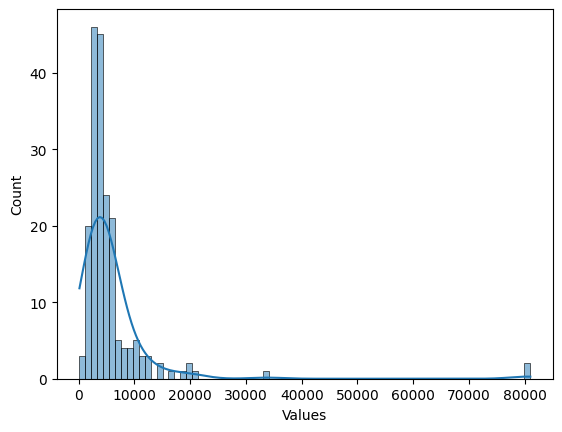

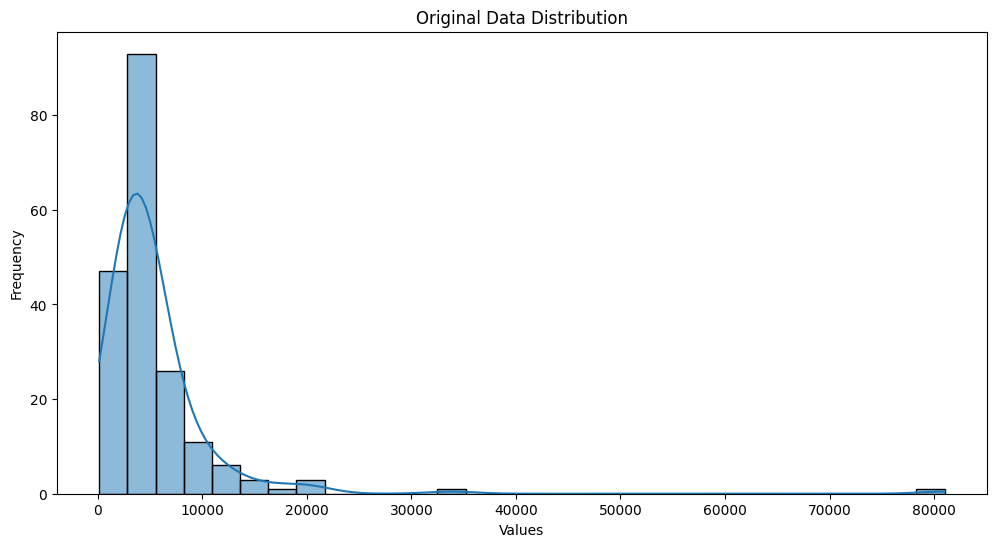

0.9647388787490094
0.02130354669824186


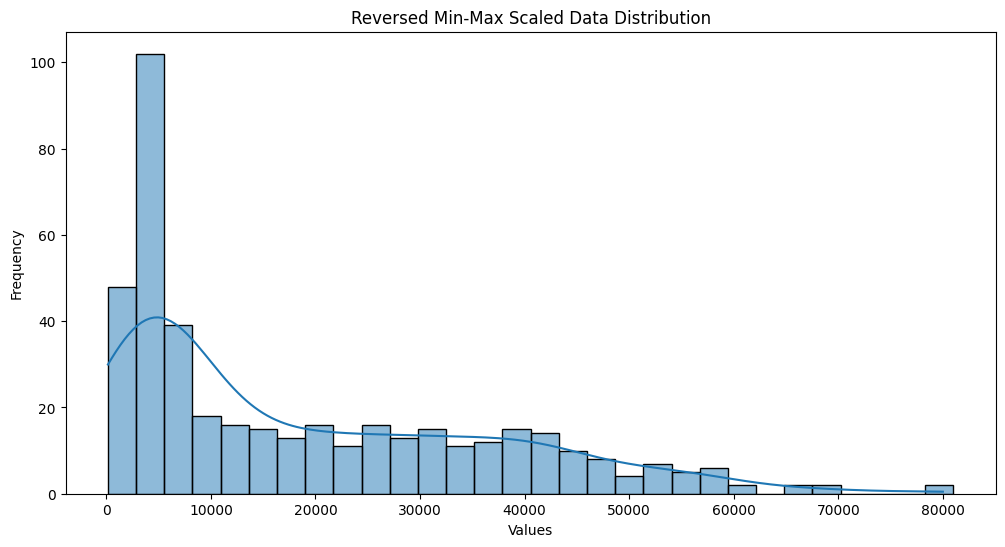

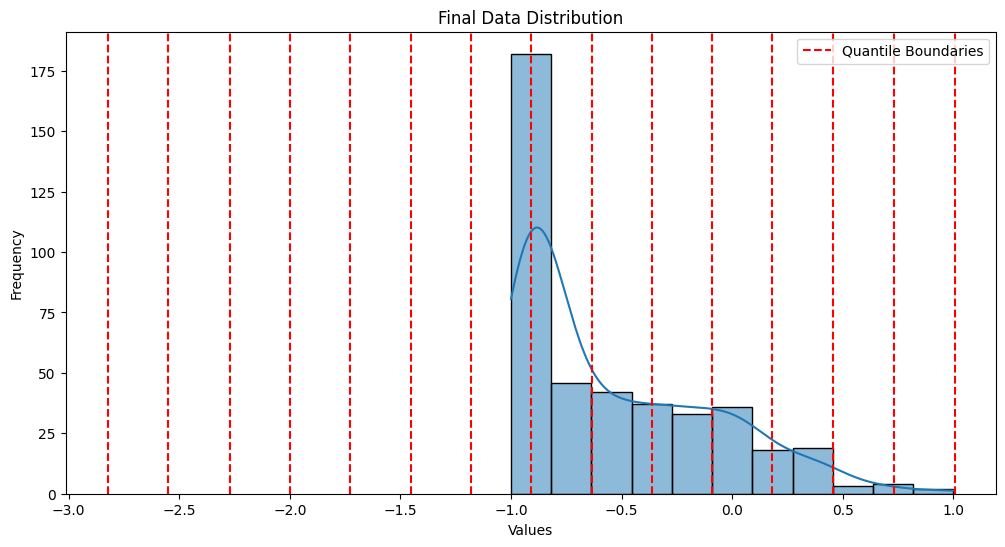

Quantile Boundaries: [-2.822348   -2.54976915 -2.27124701 -1.99786428 -1.72581881 -1.45310884
 -1.18068893 -0.90805195 -0.63541497 -0.36299505 -0.09028509  0.18176039
  0.45514311  0.73366525  1.0062441 ]
Final Deviations: [  -2.   -8.  -26.  -68. -141. -230. -199. -163. -176.  -83.  -19.   -2.
   -1.    0.]
Final Data Length: 422


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis, normaltest, norm
import matplotlib.pyplot as plt
import seaborn as sns

# Example Usage
data = pd.read_csv("/content/loan_approved.csv")

# Separate classes
y_class = data[(data['Loan_Status (Approved)'] == 'Y') ]
n_class = data[(data['Loan_Status (Approved)'] == 'N')]
df = pd.DataFrame(n_class, columns=['ApplicantIncome']).rename(columns={'ApplicantIncome': 'Values'})
y_class = pd.DataFrame(y_class, columns=['ApplicantIncome']).rename(columns={'ApplicantIncome': 'Values'})
new_point = pd.DataFrame({'Values': [80000]})

# Concatenate the new point to the existing DataFrame
df = pd.concat([df, new_point], ignore_index=True)
print("New point added:", df.tail())
sns.histplot(df['Values'], kde=True)

expected_length = len(y_class)
print("Length of 'N' class:", len(n_class))
print("Expected length:", expected_length)
diff = expected_length - len(df)
print(diff)
oversample(df,n_class,y_class,diff,expected_length,data)

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis, normaltest, norm
import matplotlib.pyplot as plt
import seaborn as sns

# Example Usage
data = pd.read_csv("/content/loan_approved.csv")

# Separate classes
y_class = data[(data['Loan_Status (Approved)'] == 'Y') ]
n_class = data[(data['Loan_Status (Approved)'] == 'N')]
df = pd.DataFrame(n_class, columns=['LoanAmount']).rename(columns={'LoanAmount': 'Values'})
y_class = pd.DataFrame(y_class, columns=['LoanAmount']).rename(columns={'LoanAmount': 'Values'})

# Concatenate the new point to the existing DataFrame
print("New point added:", df.tail())
sns.histplot(df['Values'], kde=True)

expected_length = len(y_class)
print("Length of 'N' class:", len(n_class))
print("Expected length:", expected_length)
diff = expected_length - len(df)
print(diff)

# Ensure Values column is numeric and handle missing values
df['Values'] = pd.to_numeric(df['Values'], errors='coerce')
df = df.dropna()

# Step 1: Min-Max Normalization to range [-1, 1]
if not df.empty:
    df.loc[:,'Values'] = 2 * (df['Values'] - df['Values'].min()) / (df['Values'].max() - df['Values'].min()) - 1
else:
    raise ValueError("DataFrame 'df' is empty after filtering.")

# Step 2: Define Quartile Boundaries for Normal Distribution
mean = df['Values'].mean()
median = df['Values'].median()
#std =df['Values'].std()
std = (df['Values'].max() - median) / 3.5
print("Std:", std, "Mean:", mean)

# Define the quantile boundaries with appropriate extreme boundaries using percentiles
quantiles = [0.0013, 0.0062, 0.0228, 0.0668, 0.1587, 0.3085, 0.5, 0.6915, 0.8413, 0.9332, 0.9772, 0.9938, 0.9987]
quantile_boundaries = norm.ppf(quantiles, loc=median, scale=std)

# Calculate extreme boundaries
extreme_low = quantile_boundaries[0] - std / 2
extreme_high = quantile_boundaries[-1] + std / 2

# Concatenate boundaries
quantile_boundaries = np.concatenate(([extreme_low], quantile_boundaries, [extreme_high]))

# Ensure boundaries are strictly increasing
quantile_boundaries = np.sort(quantile_boundaries)

# Step 3: Find Deviations
def quantile_deviation(data, length_data, boundaries, expected_percentages):
    observed_counts = np.histogram(data, bins=boundaries)[0]
    expected_counts = expected_percentages * length_data
    deviations = observed_counts - np.round(expected_counts[:len(observed_counts)])
    return deviations, expected_counts, observed_counts

# Make sure expected_percentages matches the number of bins (number of boundaries - 1)
expected_percentages = np.array([0.13, 0.49, 1.66, 4.40, 9.19, 14.98, 19.15, 19.15, 14.98, 9.19, 4.40, 1.66, 0.49, 0.13]) / 100

# Calculate deviations
deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], len(df['Values']), quantile_boundaries, expected_percentages)
print("Initial Deviations:", deviations)

# Step 4: Adjust Sample Size
n = len(df)
max_deviation = np.max(deviations)
while max_deviation != 0:
    max_deviation_idx = np.argmax(deviations)
    max_deviation = deviations[max_deviation_idx]
    if (max_deviation > 0):
        n = observed_counts[max_deviation_idx] / expected_percentages[max_deviation_idx]
        n = int(np.round(n))
    else:
        break
    deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], n, quantile_boundaries, expected_percentages)

print("Desired sample size based on max deviation:", n)


# Step 6: Calculate Final Deviations and Metrics
deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], n, quantile_boundaries, expected_percentages)
deviation_strengths = observed_counts / expected_counts
fractional_deficits = 1 - deviation_strengths
fractional_deficits[fractional_deficits < 0] = 0
print("Deviations after adjusting sample size:", deviations)
print("Fractional Deficits:", fractional_deficits)

# Step 7: Iteratively Add Points to Most Deficient Quantiles (one point at a time)
points_remaining = diff
while points_remaining > 0:
    # Extract fractional deficits and boundaries for quantiles within range [-1, 1]
    valid_indices = (quantile_boundaries[:-1] >= -1) & (quantile_boundaries[1:] <= 1)
    valid_fractional_deficits = fractional_deficits[valid_indices]
    valid_boundaries_start = quantile_boundaries[:-1][valid_indices]
    valid_boundaries_end = quantile_boundaries[1:][valid_indices]

    # Check if valid_fractional_deficits sum is zero to avoid division by zero
    if (valid_fractional_deficits.sum() == 0):
        # When all probabilities are zero, distribute points evenly using linspace
        remaining_points = np.linspace(max(quantile_boundaries[0], -1), min(quantile_boundaries[-1], 1), points_remaining, endpoint=False)
        random_df = pd.DataFrame({'Values': remaining_points})
        df = pd.concat([df, random_df], ignore_index=True)
        print(f"Adding points evenly in range [-1, 1]: {remaining_points}")
        points_remaining = 0  # All remaining points are added
    else:
        # Normalize fractional deficits to get probabilities
        probabilities = valid_fractional_deficits / valid_fractional_deficits.sum()

        # Select a quantile to add a point based on probabilities
        selected_idx = np.random.choice(len(probabilities), p=probabilities)

        # Add a single point to the selected quantile
        random_point = np.random.uniform(valid_boundaries_start[selected_idx], valid_boundaries_end[selected_idx])
        print(f"Adding point {random_point} in range ({valid_boundaries_start[selected_idx]}, {valid_boundaries_end[selected_idx]})")
        df = pd.concat([df, pd.DataFrame({'Values': [random_point]})], ignore_index=True)
        points_remaining -= 1

        # Recalculate deviations and fractional deficits after adding each point
        deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], n, quantile_boundaries, expected_percentages)
        deviation_strengths = observed_counts / expected_counts
        fractional_deficits = 1 - deviation_strengths
        fractional_deficits[fractional_deficits < 0] = 0

        # Recalculate valid fractional deficits
        valid_fractional_deficits = fractional_deficits[valid_indices]

    # Calculate the sum of fractional deficits for valid quantiles
    sum_fractional_deficits_valid = valid_fractional_deficits.sum()
    print("Sum of fractional deficits for quantiles within range [-1, 1]:", sum_fractional_deficits_valid)

print("Points remaining:", points_remaining)
print("Final Deviations:", deviations)
print("Fractional Deficits:", fractional_deficits)

# Remove points outside the extreme boundaries
df = df[(df['Values'] >= -1) & (df['Values'] <= 1)].reset_index(drop=True)

# Recalculate final deviations and metrics
deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], n, quantile_boundaries, expected_percentages)
skewness = skew(df['Values'])
kurt = kurtosis(df['Values'])
k2, p_value = normaltest(df['Values'])

# Print the results
print(f'Skewness: {skewness}')
print(f'Kurtosis: {kurt}')
print(f'P-value: {p_value}')

# Step 9: Visualization

# Calculate bin edges for the initial data
bin_edges = np.histogram_bin_edges(data['LoanAmount'].dropna(), bins=30)

# Plotting the original data
plt.figure(figsize=(12, 6))
sns.histplot(n_class['LoanAmount'], bins=bin_edges, kde=True)
plt.title('Original Data Distribution')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()

# Reverse Min-Max Scaling on the new data
df['OriginalValues'] = (df['Values'] + 1) / 2 * (n_class['LoanAmount'].max() - n_class['LoanAmount'].min()) + n_class['LoanAmount'].min()
print(df['OriginalValues'].skew())
print(df['OriginalValues'].kurt())

# Plotting the reversed Min-Max scaled data with the same bin edges
plt.figure(figsize=(12, 6))
sns.histplot(df['OriginalValues'], bins=bin_edges, kde=True)
plt.title('Reversed Min-Max Scaled Data Distribution')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()

# Plotting the final data
plt.figure(figsize=(12, 6))
sns.histplot(df['Values'], kde=True)
plt.title('Final Data Distribution')
plt.xlabel('Values')
plt.ylabel('Frequency')
for boundary in quantile_boundaries:
    plt.axvline(x=boundary, color='r', linestyle='--', label='Quantile Boundaries' if boundary == quantile_boundaries[1] else "")
plt.legend()
plt.show()

# Display quantile boundaries
print(f'Quantile Boundaries: {quantile_boundaries}')
print(f'Final Deviations: {deviations}')
print(f'Final Data Length: {len(df)}')


FileNotFoundError: [Errno 2] No such file or directory: '/content/loan_approved.csv'